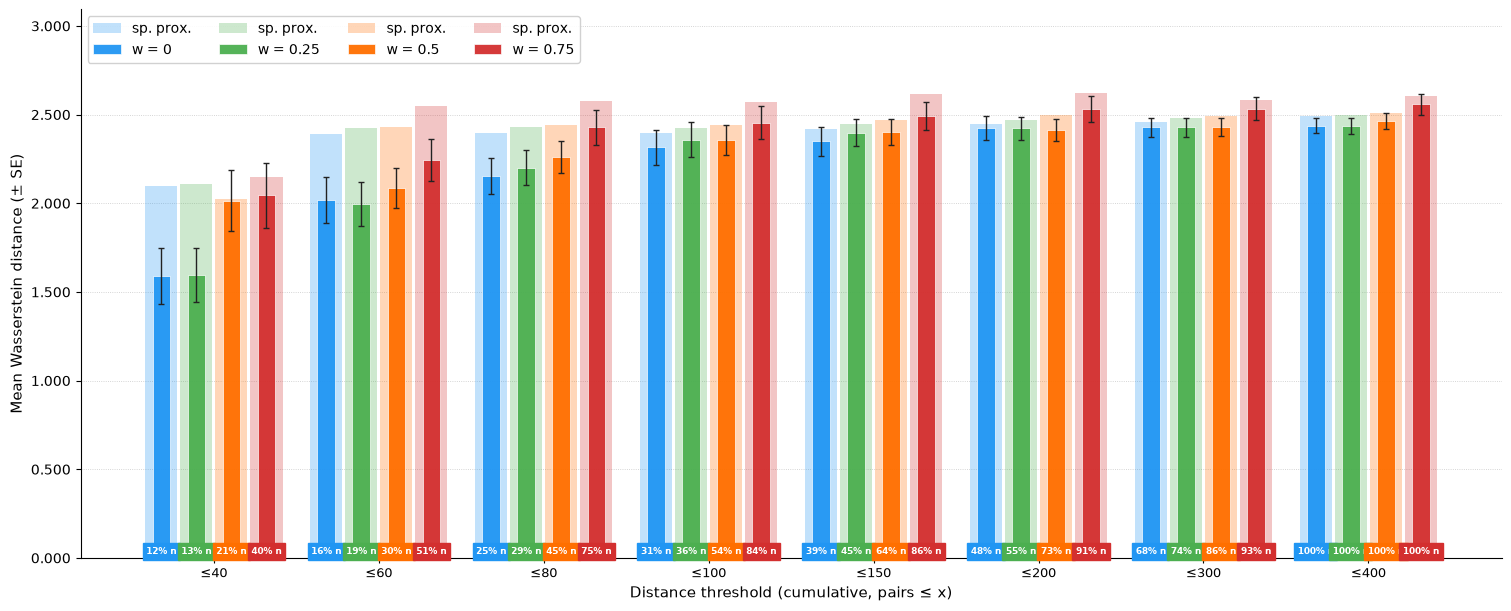

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd

# ─────────────────────────── 1. load + assemble per threshold ───────────────────────────
changed_gdf = []
spatial_gdf = []

for dist in [40, 100, 200, 400]:
    # --- feature-space pairs that changed (corrected + w0) ---
    gdf_fs = gpd.read_parquet(f'../data/fs_stratified_samples/fs_sim_all_{dist}m.parquet').reset_index()
    gdf_fs = gdf_fs.dissolve(['shot_num', 'weight'],
                             aggfunc={"wass_dist": "mean", "s2_feats": "first",
                                      "s1_feats": "first", "strata": "first"}).reset_index()
    gdf_fs['shot_num'] = gdf_fs['shot_num'].astype('str')
    gdf_fs['dist_thr'] = dist                                    # tag threshold

    # --- spatial-proximity baseline pairs ---
    geo_pairs_raw = gpd.read_parquet(f'../data/sp_stratified_samples/pairs_{dist}m_stratified_laz.parquet')
    geo_distances = (geo_pairs_raw.iloc[len(geo_pairs_raw)//2:].to_crs(25830)
                     .distance(geo_pairs_raw.iloc[:len(geo_pairs_raw)//2].to_crs(25830).geometry,
                               align=False).values)

    geo_pairs_raw = geo_pairs_raw.iloc[2150:]
    geo_pairs_raw['shot_num'] = pd.to_numeric(geo_pairs_raw['shot_num'])
    geo_sim = pd.read_csv(f'../data/sp_stratified_samples/sim_all_{dist}m.csv')
    geo_pairs_raw['geo_wass_dist'] = geo_sim.sort_values('index').wass_dist.values
    geo_pairs_raw['geo_distance'] = geo_distances
    geo_pairs_raw['shot_num'] = geo_pairs_raw['shot_num'].astype('str')
    geo_pairs_raw['dist_thr'] = dist                            # tag threshold

    changed_gdf.append(gdf_fs.to_crs(4326))
    spatial_gdf.append(geo_pairs_raw)

# ─────────────────────────── 2. build 8600 × 4 (changed + unchanged) ───────────────────────────
changed = pd.concat(changed_gdf, ignore_index=True)   # only pairs that changed, per (shot, weight, dist)
spatial = pd.concat(spatial_gdf, ignore_index=True).to_crs(4326)   # all baseline pairs, per (shot, dist)

changed = pd.concat(changed_gdf)

spatial = pd.concat(spatial_gdf)

changed_merged = changed.merge(spatial, how = 'outer', on = 'shot_num').dropna()
changed_merged['fs_distance'] = changed_merged.geometry_x.to_crs(25830).distance(changed_merged.geometry_y.to_crs(25830))

gdf_all = changed_merged

THRESHOLDS = [40, 60, 80, 100, 150, 200, 300, 400]
LABELS     = [f'≤{t}' for t in THRESHOLDS]
WEIGHTS    = [0, 0.25, 0.5, 0.75]
PALETTE    = {0: '#2196F3', 0.25: '#4CAF50', 0.5: '#FF6F00', 0.75: '#D32F2F'}

def agg_cumulative(d, v, thresholds):
    means, ses, ns = [], [], []
    for t in thresholds:
        mask = d <= t
        n = mask.sum()
        if n > 1:
            means.append(v[mask].mean())
            ses.append(v[mask].std(ddof=1) / np.sqrt(n))
        else:
            means.append(np.nan)
            ses.append(np.nan)
        ns.append(n)
    return pd.DataFrame({'mean': means, 'se': ses, 'n': ns}, index=thresholds)

stats_by_w = {}
for w in WEIGHTS:
    gdf = gdf_all[gdf_all['weight'] == w].copy()
    gdf['fs_distance'] = gdf['fs_distance'].fillna(gdf['geo_distance'])

    gdf_dist = gdf.dropna(subset=['fs_distance', 'wass_dist'])
    gdf_dist = gdf_dist[gdf_dist['fs_distance'] > 0]
    d1 = gdf_dist['fs_distance'].values.astype(float)
    v1 = gdf_dist['wass_dist'].values.astype(float)

    gdf_geo = gdf.dropna(subset=['geo_distance', 'geo_wass_dist'])
    gdf_geo = gdf_geo[gdf_geo['geo_distance'] > 0]
    d2 = gdf_geo['geo_distance'].values.astype(float)
    v2 = gdf_geo['geo_wass_dist'].values.astype(float)

    stats_by_w[w] = {
        'dist': agg_cumulative(d1, v1, THRESHOLDS),
        'geo':  agg_cumulative(d2, v2, THRESHOLDS),
    }

fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
x = np.arange(len(LABELS))
n_w = len(WEIGHTS)
slot_w = 0.85 / n_w
bg_w   = slot_w * 0.92
fg_w   = slot_w * 0.5

for gi, w in enumerate(WEIGHTS):
    dist_stats = stats_by_w[w]['dist']
    geo_stats  = stats_by_w[w]['geo']
    offset = (gi - (n_w - 1) / 2) * slot_w
    xi = x + offset

    means_geo  = geo_stats['mean'].values
    means_dist = dist_stats['mean'].values
    ses_dist   = dist_stats['se'].values
    ns_dist    = dist_stats['n'].values
    ns_geo     = geo_stats['n'].values

    ax.bar(xi, means_geo, width=bg_w, color=PALETTE[w], alpha=0.28,
           zorder=2, edgecolor='none', label=f'sp. prox.')

    ax.bar(xi, means_dist, width=fg_w, color=PALETTE[w], alpha=0.95,
           zorder=3, edgecolor='white', linewidth=0.5,
           label=f'w = {w}')
    ax.errorbar(xi, means_dist, yerr=ses_dist, fmt='none', ecolor='#222',
                elinewidth=1, capsize=2, capthick=1, zorder=4)

    # n_dist / n_geo ratio, guarded against zero denominator
    pct = np.where(means_geo != 0, (means_dist - means_geo) / means_geo * 100, np.nan)
    n_pct = np.where(ns_geo > 0, ns_dist / ns_geo * 100, np.nan)
    
    for xpos, pd_, m_dist, m_geo, nd, ng, npct in zip(xi, pct, means_dist, means_geo, ns_dist, ns_geo, n_pct):
        if np.isnan(pd_):
            continue
        sign = '+' if pd_ >= 0 else ''
        n_label = f'{npct:.0f}% n' if not np.isnan(npct) else 'n/a'
        ax.text(xpos, 0.01, f'{n_label}', ha='center', va='bottom',
                 bbox=dict(boxstyle='square,pad=.4', facecolor=PALETTE[w], edgecolor = PALETTE[w]),
                 fontsize=6.5, color='white', fontweight='bold', rotation=0, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=9)
ax.set_xlabel('Distance threshold (cumulative, pairs ≤ x)', fontsize=11)
ax.set_ylabel('Mean Wasserstein distance (± SE)', fontsize=11)
# ax.set_title('Feature-space (solid) vs spatial-proximity (pale) pairing, by weight and cumulative threshold\n'
#              'Text = n_feature-space / n_geo per subset',
#              fontsize=12, fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10, frameon=True, framealpha=0.9, edgecolor='#ccc', ncol=4, loc='upper left')
ax.margins(y=0.18)

# plt.savefig('paper_figures/wass_dist_bins_overlay_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()